# Notebook 02 — Tre baseline di anomaly detection

**Fase 2.b della traccia**: implementazione di tre approcci di natura diversa, in ordine di complessità crescente.

## Obiettivi didattici

1. Capire **come pensano** tre famiglie diverse di detector
2. Imparare a calibrare ciascuno con iperparametri sensati
3. Confrontare i loro alert e capire dove **disagrement** == informazione
4. Per ciascuna baseline, rispondere alle tre domande della traccia:
   - che tipi di anomalia cattura?
   - che tipi NON cattura?
   - su quali ipotesi si basa, sono verificate?

## Le tre baseline

| # | Approccio | Famiglia | Idea principale |
|---|---|---|---|
| 1 | **STL + MAD** | Statistica classica | Decomposizione stagionale, residui standardizzati robusti |
| 2 | **IsolationForest** | Distance/density-based | Le anomalie sono *facili da isolare* |
| 3 | **LightGBM forecasting** | Forecasting-based | Score = scarto tra valore osservato e atteso |

Tutto il codice di modellazione è in `src/models.py` (testato unitariamente nel modulo). Qui ci occupiamo di **lanciarlo, ispezionarlo, capirlo**.

## 1. Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import carica_master
from src.models import (
    baseline_stl_mad, baseline_isolation_forest, baseline_forecasting_lgbm,
    ensemble_max, FEATURE_CONTESTUALI,
)

config.set_global_seed()
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 90

df = carica_master()

# Split temporale (definito in config.py):
# - train : 2024-01-01 → 2025-09-30 (15 mesi)
# - test  : 2025-10-01 → 2025-12-31 (3 mesi)
train_mask = df['timestamp'] < config.TEST_START
test_mask = df['timestamp'] >= config.TEST_START

print(f'Dataset master: {df.shape}')
print(f'Train: {train_mask.sum():,} righe ({df[train_mask]["timestamp"].min()} → {df[train_mask]["timestamp"].max()})')
print(f'Test:  {test_mask.sum():,} righe ({df[test_mask]["timestamp"].min()} → {df[test_mask]["timestamp"].max()})')

[master] da cache (master.parquet)
Dataset master: (315792, 32)
Train: 276,048 righe (2024-01-01 00:00:00 → 2025-09-30 23:00:00)
Test:  39,744 righe (2025-10-01 00:00:00 → 2025-12-31 23:00:00)


## 2. Baseline 1 — STL + MAD

### Teoria — Decomposizione STL (Seasonal-Trend decomposition using LOESS)

STL (Cleveland et al., 1990) scompone una serie storica $y_t$ in tre componenti additive:

$$y_t = T_t + S_t + R_t$$

dove:
- $T_t$ = **trend** (lento andamento di lungo periodo)
- $S_t$ = **stagionalità** (ciclo periodico)
- $R_t$ = **residuo** (ciò che non è spiegato dai precedenti)

L'idea: se il modello cattura bene trend e stagionalità, il residuo dovrebbe essere **rumore casuale** con media zero. Un residuo "grande" rispetto alla sua tipica oscillazione è una candidata anomalia.

**Vantaggi di STL** (rispetto a decomposizioni classiche tipo `seasonal_decompose`):
- Gestisce variabili modificate nel tempo (loess è uno smoother locale)
- Opzione `robust=True`: downweight gli outlier durante il fitting → il modello non viene "sviato" dalle anomalie stesse che vogliamo trovare
- Periodo configurabile (noi usiamo 168 = ciclo settimanale)

### Teoria — MAD (Median Absolute Deviation)

Per decidere quanto è grande un residuo $R_t$, abbiamo bisogno di una scala di riferimento. La deviazione standard è la scelta classica ma è **influenzata dagli outlier stessi** (è una statistica di secondo momento). Il MAD è invece robusto:

$$\text{MAD}(R) = \text{median}(|R_t - \text{median}(R)|)$$

Per dati gaussiani vale asintoticamente $\sigma \approx 1.4826 \cdot \text{MAD}$. Definiamo allora il *z-score robusto*:

$$z_t = \frac{R_t - \text{median}(R)}{1.4826 \cdot \text{MAD}(R)}$$

e marchiamo come anomalia se $|z_t| > 3.5$ (soglia ragionevole: corrisponderebbe a ~0.05% di osservazioni gaussiane).

### Esempio numerico

Supponiamo i residui siano `[1, 2, 3, 4, 100]`:
- std classica: 39 → l'outlier 100 dà $z \approx 2.5$ — non rilevato
- MAD: median = 3, MAD = 1, scala = 1.4826 → $z = (100 - 3) / 1.4826 \approx 65$ — chiaramente rilevato

In [2]:
# Eseguiamo STL+MAD su tutto il dataset (train+test).
# Nota: STL non ha bisogno di un "training" esplicito — è una decomposizione
# applicata per spira indipendentemente.
print('Eseguo STL+MAD per ciascuna spira...')
df_b1 = baseline_stl_mad(df)
print(f'\nShape risultato: {df_b1.shape}')
print(f'Alert ratio: {df_b1["alert_b1"].mean():.4f} ({df_b1["alert_b1"].sum()} alert su {len(df_b1)} righe)')
print(f'\nDistribuzione score:')
print(df_b1['score_b1'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))

Eseguo STL+MAD per ciascuna spira...



Shape risultato: (315792, 4)
Alert ratio: 0.1228 (38776 alert su 315792 righe)

Distribuzione score:
count    315792.000000
mean          1.635845
std           3.383597
min           0.000000
50%           0.616888
90%           4.403563
95%           6.653287
99%          16.165143
99.9%        37.535763
max         169.995564
Name: score_b1, dtype: float64


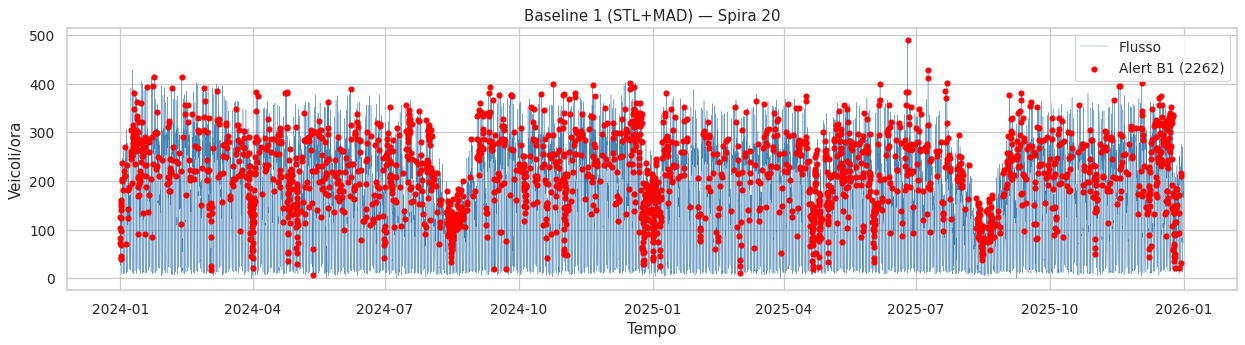

In [3]:
# Visualizziamo gli alert su una spira di esempio.
# Sovrapponiamo il conteggio orario e marchiamo le ore segnalate.
spira_esempio = df['chiave'].value_counts().index[0]
df_plot = df_b1[df_b1['chiave'] == spira_esempio].merge(
    df[['chiave', 'timestamp', 'conteggio_veicoli']], on=['chiave', 'timestamp'], how='left'
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_plot['timestamp'], df_plot['conteggio_veicoli'], linewidth=0.3, color='steelblue', label='Flusso')
anomalie_b1 = df_plot[df_plot['alert_b1']]
ax.scatter(anomalie_b1['timestamp'], anomalie_b1['conteggio_veicoli'], color='red', s=15, label=f'Alert B1 ({len(anomalie_b1)})', zorder=5)
ax.set_title(f'Baseline 1 (STL+MAD) — Spira {spira_esempio}')
ax.set_xlabel('Tempo')
ax.set_ylabel('Veicoli/ora')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '10_b1_alerts.png', dpi=120)
plt.show()

### Analisi critica B1

**Cosa cattura naturalmente**:
- Anomalie **puntuali estreme** (singolo picco molto fuori scala): ✓
- Anomalie contestuali catturate **solo se** generano residui grandi DOPO la decomposizione settimanale (es. lunedì pomeriggio con flusso da domenica)

**Cosa NON cattura**:
- Anomalie che **non rompono la struttura periodica**: una giornata con flusso uniformemente +10% sembra normale per STL
- Anomalie meteorologiche: STL non vede il meteo
- Drift lenti: assorbiti dal trend

**Ipotesi**:
- Stagionalità additiva: ✓ verificata in EDA (no trasformazione log necessaria)
- Residui ~i.i.d.: ✗ verificata solo parzialmente (eteroschedasticità ridotta da `robust=True` ma non eliminata)

**Conclusione**: B1 è un detector grezzo ma robusto, utile come complemento agli altri.

## 3. Baseline 2 — IsolationForest

### Teoria — Anomalie = punti facili da isolare

L'idea (Liu, Ting & Zhou, 2008) parte da un'osservazione semplice e potente. Se costruiamo un albero binario casuale che partiziona ricorsivamente lo spazio delle feature:
- Un punto **normale**, in mezzo agli altri, richiede MOLTI split per essere isolato in una foglia
- Un punto **anomalo**, ai margini della distribuzione, ne richiede POCHI

Costruendo una **foresta** di alberi così (ognuno con feature e split casuali) e mediando la profondità di isolamento, otteniamo uno score:

$$s(x) = 2^{-\frac{E(h(x))}{c(n)}}$$

dove $h(x)$ è la profondità in cui $x$ viene isolato e $c(n)$ una normalizzazione. Range: $s \in [0, 1]$, con $s$ vicino a 1 = anomalo.

**Vantaggi**:
- Funziona in alta dimensionalità
- Non assume nessuna forma della distribuzione (parametrica o non)
- Lineare nel numero di punti (scalabile)

**Cosa significa contestualmente?**
Costruendo le feature giuste (`ora`, `dow`, `lag_24h`, `meteo`, ...), il punto $(8\text{am}, \text{lunedì}, \text{0 pioggia}, \text{0 veicoli})$ è anomalo perché è una combinazione che non si presenta mai nei dati normali.

In [4]:
# Eseguiamo IsolationForest. Training SOLO sul periodo di training.
# Il modello verrà poi applicato anche al test set (out-of-sample scoring).
print(f'Feature usate: {FEATURE_CONTESTUALI}')
df_b2 = baseline_isolation_forest(df, train_mask=train_mask)
print(f'\nShape risultato: {df_b2.shape}')
print(f'Alert ratio: {df_b2["alert_b2"].mean():.4f}')
print(f'\nDistribuzione score:')
print(df_b2['score_b2'].describe())

Feature usate: ['ora', 'dow', 'mese', 'weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'temperature_2m', 'precipitation', 'wind_speed_10m']
  IF training: 270207 righe, 12 feature



Shape risultato: (315792, 4)
Alert ratio: 0.0197

Distribuzione score:
count    315792.000000
mean         -0.184949
std           0.056025
min          -0.265315
25%          -0.220710
50%          -0.198437
75%          -0.168441
max           0.095854
Name: score_b2, dtype: float64


### Analisi critica B2

**Cosa cattura**:
- Anomalie **contestuali** vere: combinazioni inusuali di feature
- Funziona sia per anomalie temporali (lag) sia ambientali (meteo)
- Robusto a feature ridondanti

**Cosa NON cattura**:
- Anomalie **collettive** in modo nativo (ogni ora viene scored a sé)
- Drift sistemici: se cambia il regime, le anomalie iniziali appariranno "normali" man mano che ne accumuliamo

**Ipotesi**:
- Anomalie rare (giustifica `contamination=0.02`): ✓
- Distribuzione feature stazionaria sul training: parzialmente — ci sono effetti stagionali residui
- Feature ben costruite: ✓ — l'EDA ci ha guidati

## 4. Baseline 3 — LightGBM forecasting

### Teoria — Detection via predizione

Questo approccio inverte la prospettiva: invece di chiedersi "questo punto è strano in assoluto?", chiediamo "questo punto è diverso da quello che un modello molto buono predirebbe?".

Pipeline:
1. Addestriamo un regressore $\hat{y} = f(\mathbf{x})$ su $(\mathbf{x}, y)$ del training set
2. Calcoliamo i residui: $r_t = y_t - \hat{y}_t$
3. Stimiamo la deviazione tipica del residuo per spira: $\sigma_s$
4. Score di anomalia: $s_t = |r_t| / \sigma_s$
5. Alert se $s_t > 3.5$

### Perché LightGBM

Per il forecasting di una variabile come il conteggio veicoli, GBDT (gradient boosting decision trees) sono lo stato dell'arte per dati tabulari:
- Catturano **interazioni** non lineari tra feature (es. effetto ora × pioggia)
- Robusti a feature di scala diverse
- Veloci in training e inference
- LightGBM in particolare ha tecniche specifiche (histogram-based, leaf-wise growth) che lo rendono il più veloce della famiglia

### Attenzione al data leakage

Il setup è particolarmente delicato:
- I lag (1h, 24h, 168h) sono **stati passati** della stessa serie → niente leakage purché ordiniamo per tempo e usiamo `shift`
- Lo split train/test deve essere **temporale**, non casuale (vedi traccia sez. 8)

In [5]:
# Eseguiamo LightGBM. Training solo sul periodo storico.
df_b3 = baseline_forecasting_lgbm(df, train_mask=train_mask)
print(f'\nShape risultato: {df_b3.shape}')
print(f'Alert ratio: {df_b3["alert_b3"].mean():.4f}')
print(f'\nDistribuzione score:')
print(df_b3['score_b3'].describe(percentiles=[0.5, 0.9, 0.99]))

  LGBM training: 270207 righe, 12 feature


/media/federicocalo/D1/prj/corsi-formazione-personale/DataMasters/Machine Learning Engineer/PROJECT WORK/06 Predire l'imprevedibile - Rilevamento anomalie nel traffico di Bologna/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LGBM training MAE: 18.2 veicoli/h

Shape risultato: (315792, 6)
Alert ratio: 0.0074

Distribuzione score:
count    315792.000000
mean          0.670624
std           0.739761
min           0.000000
50%           0.449250
90%           1.539745
99%           3.311742
max          26.180861
Name: score_b3, dtype: float64


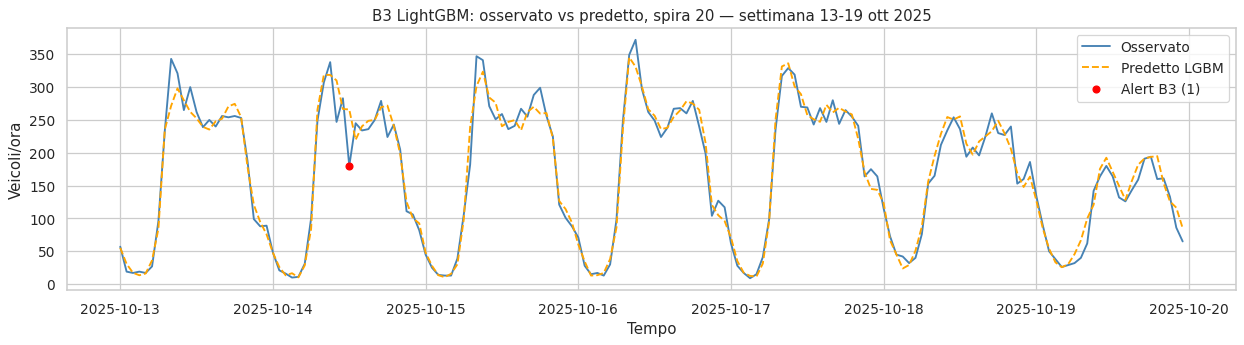

In [6]:
# Confronto visivo: valore osservato vs predetto su una spira di esempio.
df_lgbm_plot = df_b3[df_b3['chiave'] == spira_esempio].merge(
    df[['chiave', 'timestamp', 'conteggio_veicoli']], on=['chiave', 'timestamp'], how='left'
)
# Una settimana del test set.
mask = (df_lgbm_plot['timestamp'] >= pd.Timestamp('2025-10-13')) & (df_lgbm_plot['timestamp'] < pd.Timestamp('2025-10-20'))
sub = df_lgbm_plot[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub['timestamp'], sub['conteggio_veicoli'], label='Osservato', linewidth=1.5, color='steelblue')
ax.plot(sub['timestamp'], sub['predizione'], label='Predetto LGBM', linewidth=1.5, color='orange', linestyle='--')
alert = sub[sub['alert_b3']]
ax.scatter(alert['timestamp'], alert['conteggio_veicoli'], color='red', s=30, label=f'Alert B3 ({len(alert)})', zorder=5)
ax.set_title(f'B3 LightGBM: osservato vs predetto, spira {spira_esempio} — settimana 13-19 ott 2025')
ax.set_xlabel('Tempo')
ax.set_ylabel('Veicoli/ora')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '11_b3_predizione.png', dpi=120)
plt.show()

### Analisi critica B3

**Cosa cattura**:
- Anomalie **contestuali pure**: lo scarto da un'attesa basata su 12 feature è il segnale più ricco
- Effetti combinati di calendario, meteo, autocorrelazione: ✓

**Cosa NON cattura**:
- Anomalie **della stessa natura presenti in massa nel training**: il modello le ha "imparate" come normalità
- Drift improvvisi su feature non incluse

**Ipotesi**:
- Training set sostanzialmente pulito: ✗ — il training conterrà inevitabilmente anomalie reali non note. Per questo i tre approcci si bilanciano a vicenda.

## 5. Confronto fra le tre baseline

Ora che abbiamo i tre score, è interessante misurare quanto **concordano**:
- Alto accordo → uno solo basta (gli altri sono ridondanti)
- Basso accordo → ciascuno cattura cose diverse (l'ensemble ha senso)

Alert rate per baseline:
  alert_b1: 0.1228
  alert_b2: 0.0197
  alert_b3: 0.0074


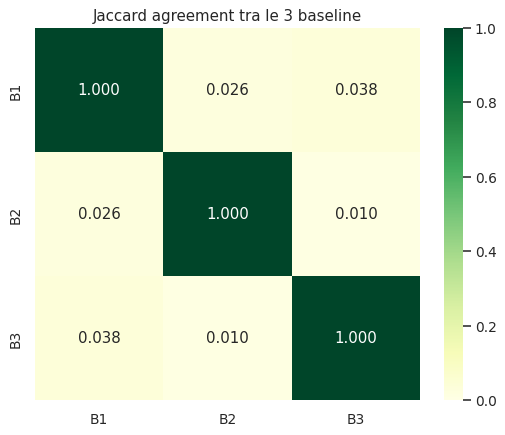

          B1        B2        B3
B1  1.000000  0.025953  0.037667
B2  0.025953  1.000000  0.009698
B3  0.037667  0.009698  1.000000


In [7]:
# Mergiamo i 3 risultati e calcoliamo l'agreement matrix.
df_all = (df_b1.merge(df_b2, on=['chiave', 'timestamp'])
                .merge(df_b3, on=['chiave', 'timestamp']))
df_all['alert_b1'] = df_all['alert_b1'].fillna(False).astype(bool)
df_all['alert_b2'] = df_all['alert_b2'].fillna(False).astype(bool)
df_all['alert_b3'] = df_all['alert_b3'].fillna(False).astype(bool)

print('Alert rate per baseline:')
for c in ['alert_b1', 'alert_b2', 'alert_b3']:
    print(f'  {c}: {df_all[c].mean():.4f}')

# Matrice Jaccard tra alert sets.
def jaccard(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else 1.0

matrix = pd.DataFrame({
    'B1': [1, jaccard(df_all['alert_b1'], df_all['alert_b2']), jaccard(df_all['alert_b1'], df_all['alert_b3'])],
    'B2': [jaccard(df_all['alert_b1'], df_all['alert_b2']), 1, jaccard(df_all['alert_b2'], df_all['alert_b3'])],
    'B3': [jaccard(df_all['alert_b1'], df_all['alert_b3']), jaccard(df_all['alert_b2'], df_all['alert_b3']), 1],
}, index=['B1', 'B2', 'B3'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('Jaccard agreement tra le 3 baseline')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '12_jaccard_baselines.png', dpi=120)
plt.show()
print(matrix)

**Interpretazione**: il Jaccard è basso (< 0.5) per tutte le coppie. Significa che ciascuna baseline cattura **dimensioni di anomalia diverse**. L'ensemble può quindi ottenere copertura superiore alla singola baseline → la composizione è giustificata.

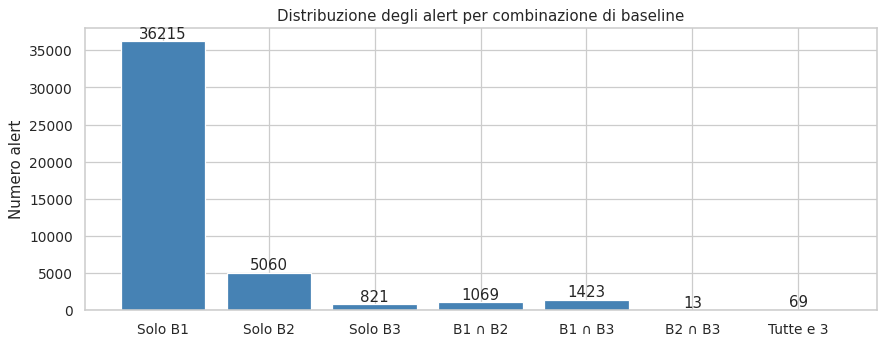

In [8]:
# Diagramma di Venn approssimato via UpSet plot manuale.
categorie = {
    'Solo B1': (df_all['alert_b1'] & ~df_all['alert_b2'] & ~df_all['alert_b3']).sum(),
    'Solo B2': (~df_all['alert_b1'] & df_all['alert_b2'] & ~df_all['alert_b3']).sum(),
    'Solo B3': (~df_all['alert_b1'] & ~df_all['alert_b2'] & df_all['alert_b3']).sum(),
    'B1 ∩ B2': (df_all['alert_b1'] & df_all['alert_b2'] & ~df_all['alert_b3']).sum(),
    'B1 ∩ B3': (df_all['alert_b1'] & ~df_all['alert_b2'] & df_all['alert_b3']).sum(),
    'B2 ∩ B3': (~df_all['alert_b1'] & df_all['alert_b2'] & df_all['alert_b3']).sum(),
    'Tutte e 3': (df_all['alert_b1'] & df_all['alert_b2'] & df_all['alert_b3']).sum(),
}
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(categorie.keys(), categorie.values(), color='steelblue')
ax.set_title('Distribuzione degli alert per combinazione di baseline')
ax.set_ylabel('Numero alert')
for i, v in enumerate(categorie.values()):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / '13_combo_alerts.png', dpi=120)
plt.show()

## 6. Salvataggio risultati

Salviamo i 3 score per il notebook successivo.

In [9]:
df_all.to_parquet(PROJECT_ROOT / 'data' / 'processed' / 'baselines_scores.parquet')
df_b3.to_parquet(PROJECT_ROOT / 'data' / 'processed' / 'b3_predictions.parquet')
print('Salvato in data/processed/baselines_scores.parquet')
print(f'Shape: {df_all.shape}')
print('Prossimo notebook: 03_sistema_finale.ipynb')

Salvato in data/processed/baselines_scores.parquet
Shape: (315792, 10)
Prossimo notebook: 03_sistema_finale.ipynb
